In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style settings
sns.set_theme(style="whitegrid")

# Load datasets
country = pd.read_csv("country_wise_latest.csv")
daily = pd.read_csv("covid_19_clean_complete.csv")

# Quick overview function
def preview(df, name):
    print(f"{name} Shape:", df.shape)
    print(df.head())
    print("Columns:", list(df.columns))
    print("-" * 40)

# Preview both datasets
preview(country, "Country Data")
preview(daily, "Daily Data")

Country Data Shape: (187, 15)
  Country/Region  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.34   
3              0                5.73                  88.53   
4              0                4.32                  25.47   

   Deaths / 100 Recovered  Confirmed last week  1 week change  \
0                    5.04              

##Data Cleaning

In [ ]:
#Cleaning the country level file
print('Missing values in country file:')
country.isnull().sum()

Missing values in country file:


,0
Country/Region,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
New cases,0
New deaths,0
New recovered,0
Deaths / 100 Cases,0
Recovered / 100 Cases,0


In [ ]:
print('Missing values in daily file')
print(daily.isnull().sum())

# Fix the date column first, converting errors to NaT
daily['Date'] = pd.to_datetime(daily['Date'], errors='coerce')

# Drop rows where 'Date' is NaT, as they are unparseable and cannot be used for time series plotting
daily.dropna(subset=['Date'], inplace=True)

# Now fill remaining missing values in other columns.
# Fill NaNs in 'Province/State' and 'WHO Region' with 'Unknown'
daily['Province/State'] = daily['Province/State'].fillna('Unknown')
daily['WHO Region'] = daily['WHO Region'].fillna('Unknown')

# Fill NaNs in numeric columns (Confirmed, Deaths, Recovered, Active) with 0
daily[['Confirmed', 'Deaths', 'Recovered', 'Active']] = daily[['Confirmed', 'Deaths', 'Recovered', 'Active']].fillna(0)

#Pull out the month and year from date
daily['Month'] = daily['Date'].dt.month
daily['Year'] = daily['Date'].dt.year

print("Cleaned Daily files:")
print(daily.dtypes)

Missing values in daily file
Province/State    0
Country/Region    0
Lat               0
Long              0
Date              0
Confirmed         0
Deaths            0
Recovered         0
Active            0
WHO Region        0
Month             0
Year              0
dtype: int64
Cleaned Daily files:
Province/State            object
Country/Region            object
Lat                      float64
Long                     float64
Date              datetime64[ns]
Confirmed                float64
Deaths                   float64
Recovered                float64
Active                   float64
WHO Region                object
Month                      int32
Year                       int32
dtype: object


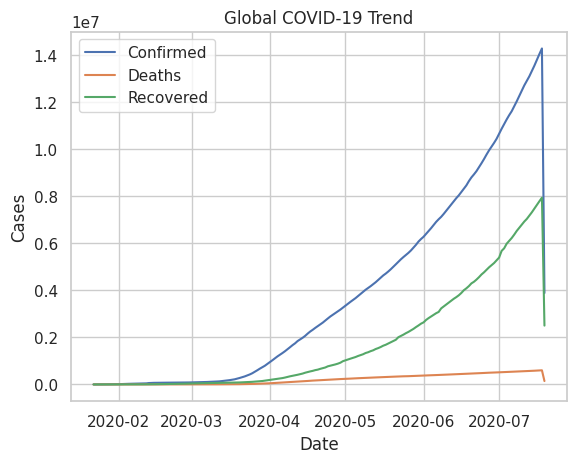

In [ ]:
# Group data by date
global_daily = daily.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum()

# Plot
plt.figure()

plt.plot(global_daily.index, global_daily['Confirmed'], label='Confirmed')
plt.plot(global_daily.index, global_daily['Deaths'], label='Deaths')
plt.plot(global_daily.index, global_daily['Recovered'], label='Recovered')

plt.title('Global COVID-19 Trend')
plt.xlabel('Date')
plt.ylabel('Cases')

plt.legend()
plt.show()

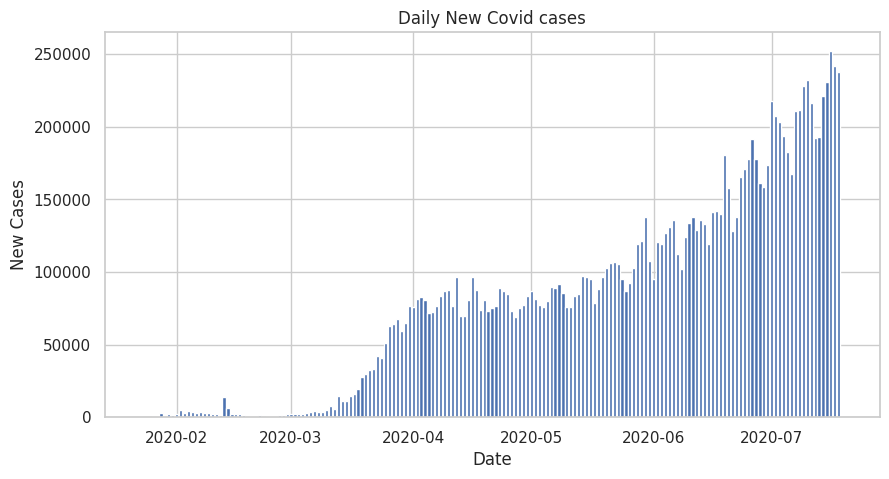

In [ ]:
#chart5:New cases per day globally
global_daily['New_Cases'] = global_daily['Confirmed'].diff()

global_daily['New_Cases'] = global_daily['New_Cases'].clip(lower=0)

plt.figure(figsize=(10,5))

plt.bar(global_daily.index,global_daily['New_Cases'])
plt.title('Daily New Covid cases')
plt.xlabel('Date')
plt.ylabel('New Cases')

plt.show()

In [ ]:
country['Country/Region'].nunique()
country[['Confirmed','Deaths','Recovered']].sum()

,0
Confirmed,16480485
Deaths,654036
Recovered,9468087


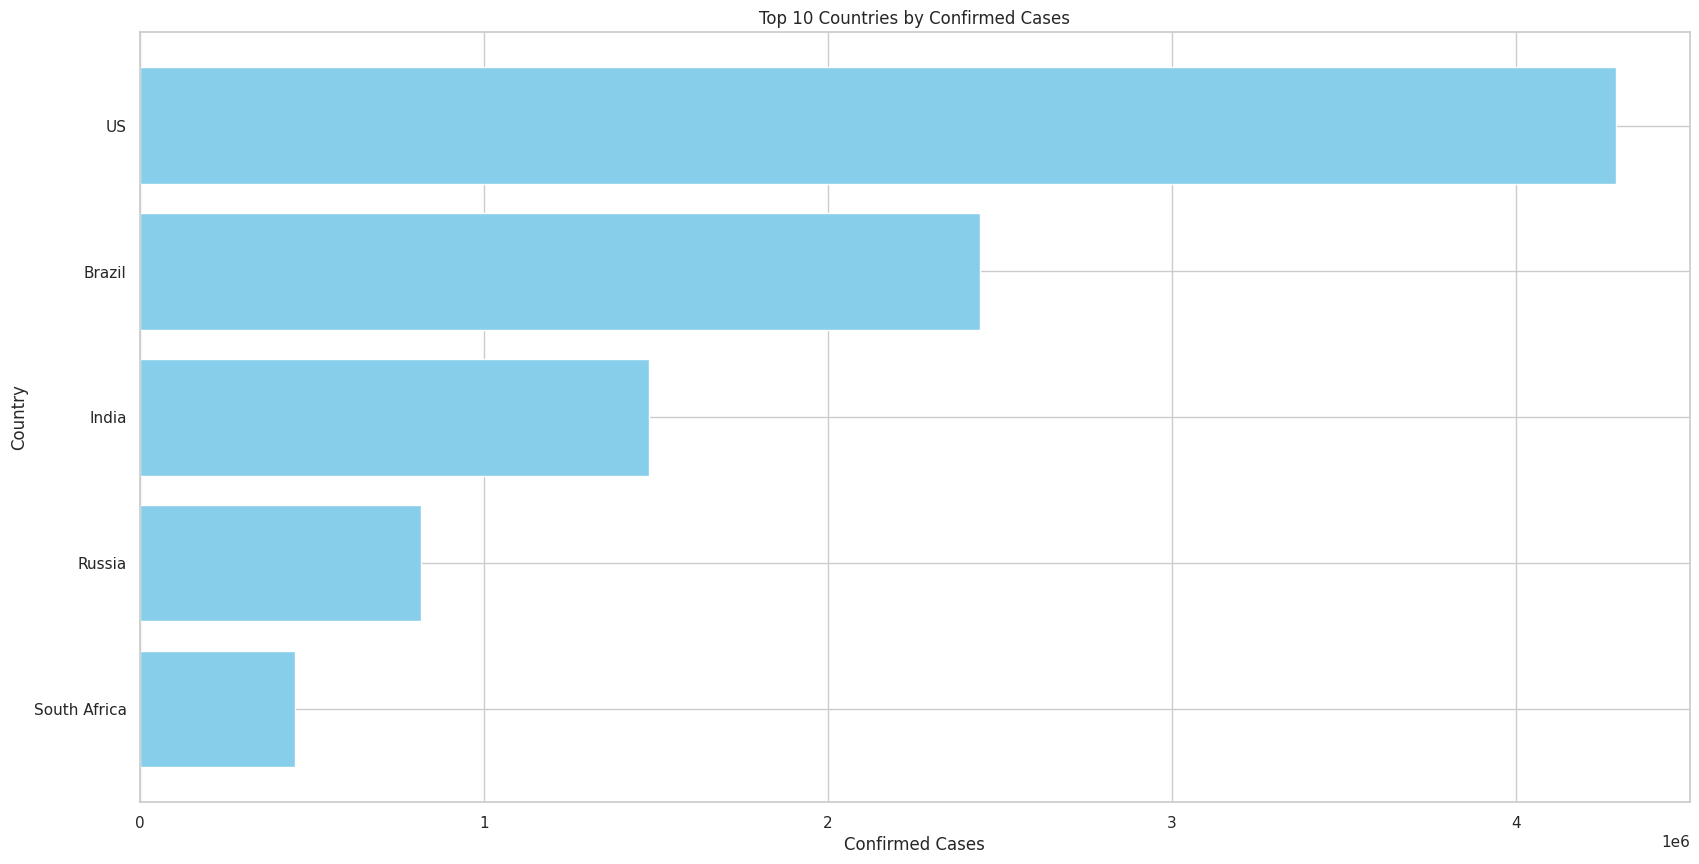

In [ ]:
#Chart 1:Top 10 countries by confirmed cases
top_10_Confirmed = country.sort_values(by='Confirmed', ascending=False).head()

plt.figure(figsize=(20, 10))
plt.barh(top_10_Confirmed['Country/Region'], top_10_Confirmed['Confirmed'], color='skyblue')
plt.xlabel('Confirmed Cases')
plt.ylabel('Country')
plt.title('Top 10 Countries by Confirmed Cases')
plt.gca().invert_yaxis()
plt.show()

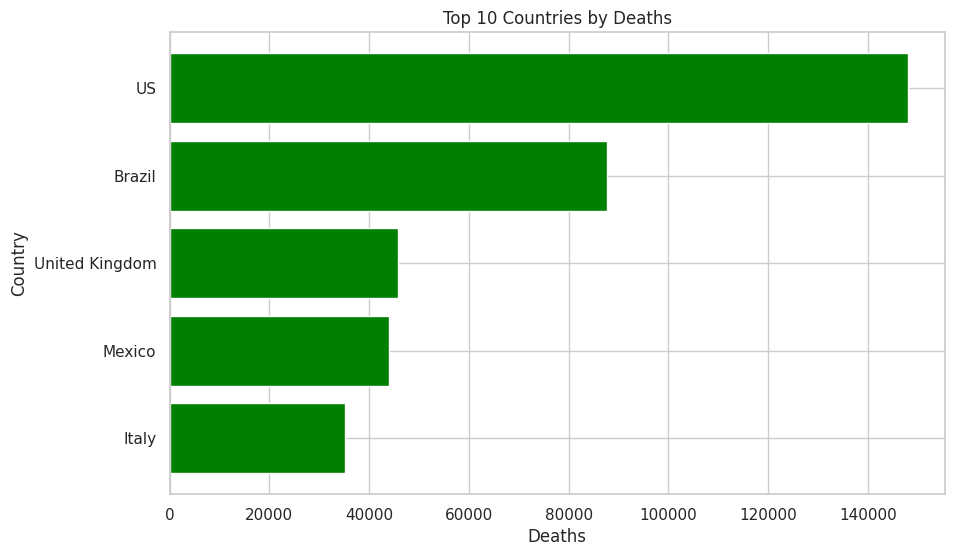

In [ ]:
#chart2:top 10 countries by death
top_10_Deaths = country.sort_values(by='Deaths', ascending=False).head()

plt.figure(figsize=(10, 6))
plt.barh(top_10_Deaths['Country/Region'],top_10_Deaths['Deaths'],color='green')
plt.xlabel('Deaths')
plt.ylabel('Country')
plt.title('Top 10 Countries by Deaths')
plt.gca().invert_yaxis()
plt.show()


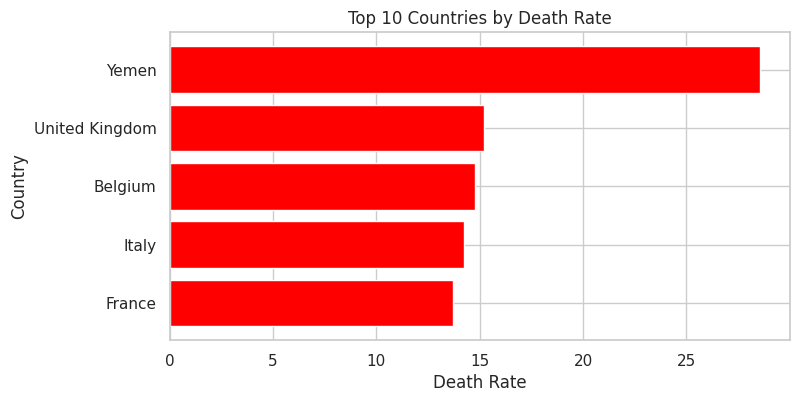

In [ ]:
#Chart3:Death rate by countries
country['Death_Rate'] = ((country['Deaths'] / country['Confirmed']) * 100).round(2)
top_10_Death_Rate = country.sort_values(by='Death_Rate', ascending=False).head()

plt.figure(figsize=(8, 4))
plt.barh(top_10_Death_Rate['Country/Region'], top_10_Death_Rate['Death_Rate'], color='red')
plt.xlabel('Death Rate')
plt.ylabel('Country')
plt.title('Top 10 Countries by Death Rate')
plt.gca().invert_yaxis()
plt.show()

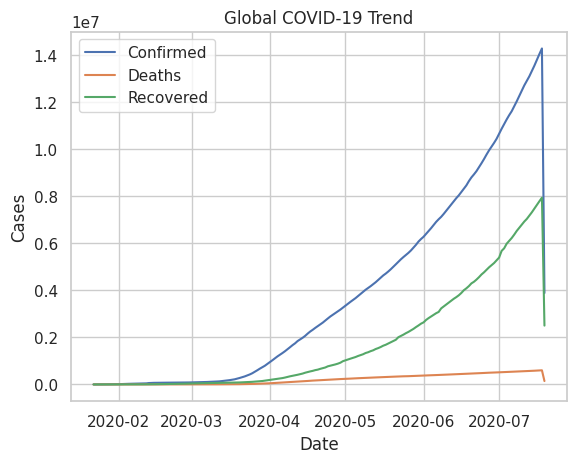

In [ ]:
# Group data by date
global_daily = daily.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum()

# Plot
plt.figure()

plt.plot(global_daily.index, global_daily['Confirmed'], label='Confirmed')
plt.plot(global_daily.index, global_daily['Deaths'], label='Deaths')
plt.plot(global_daily.index, global_daily['Recovered'], label='Recovered')

plt.title('Global COVID-19 Trend')
plt.xlabel('Date')
plt.ylabel('Cases')

plt.legend()
plt.show()

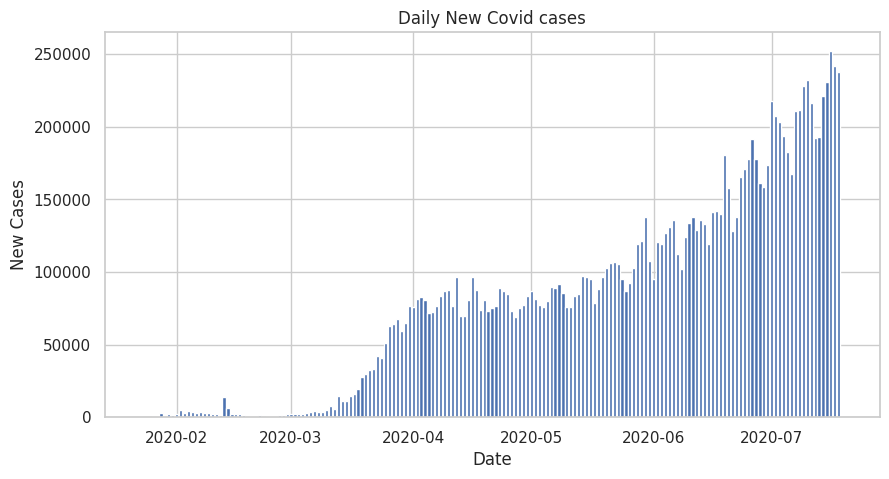

In [ ]:
#chart5:New cases per day globally
global_daily['New_Cases'] = global_daily['Confirmed'].diff()

global_daily['New_Cases'] = global_daily['New_Cases'].clip(lower=0)

plt.figure(figsize=(10,5))

plt.bar(global_daily.index,global_daily['New_Cases'])
plt.title('Daily New Covid cases')
plt.xlabel('Date')
plt.ylabel('New Cases')

plt.show()

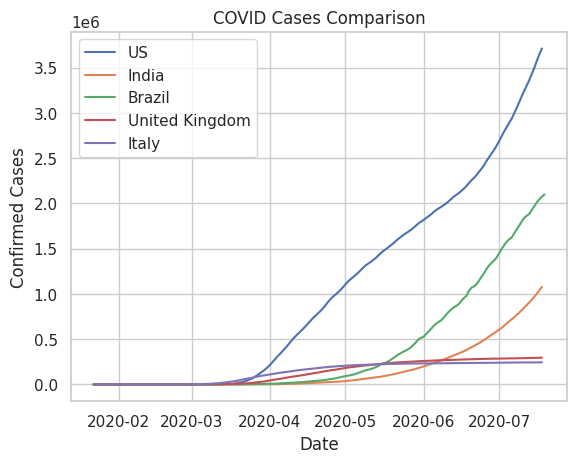

In [ ]:
#chart6:Cases over time for specific countries
# Countries to compare
countries = ['US', 'India', 'Brazil', 'United Kingdom', 'Italy']

plt.figure()

for c in countries:
    data = daily[daily['Country/Region'] == c]
    data = data.groupby('Date')['Confirmed'].sum()

    plt.plot(data.index, data.values, label=c)

plt.title('COVID Cases Comparison')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')

plt.legend()
plt.show()

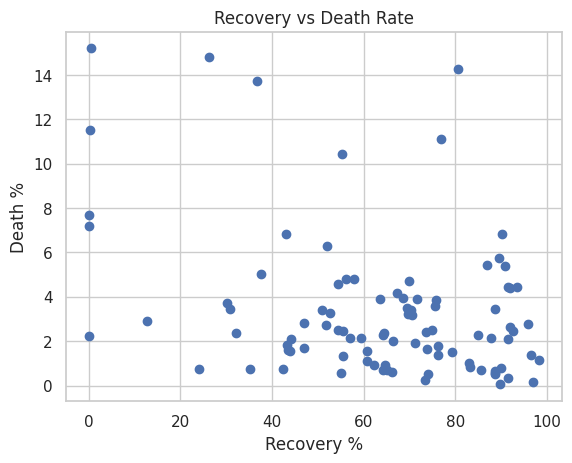

In [ ]:
#chart6:Recovery Rate VS Death Rate
# Calculate rates
country['Recovery %'] = (country['Recovered'] / country['Confirmed'] * 100).round(2)
country['Death %'] = (country['Deaths'] / country['Confirmed'] * 100).round(2)

# Filter countries with enough cases
data = country[country['Confirmed'] > 5000]

# Plot
plt.figure()

plt.scatter(data['Recovery %'], data['Death %'])

plt.title('Recovery vs Death Rate')
plt.xlabel('Recovery %')
plt.ylabel('Death %')

plt.show()

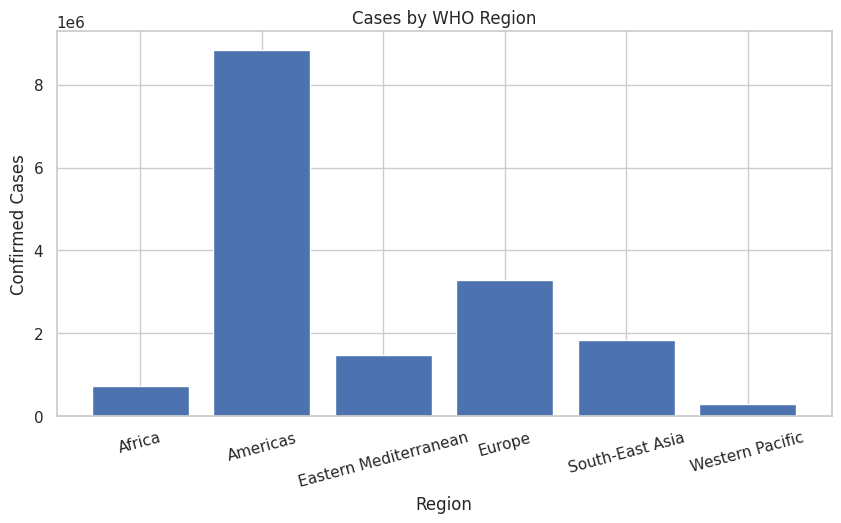

In [ ]:
#chart8:Cases by WHO region
# Check if column exists
if 'WHO Region' in country.columns:

    # Group by region
    region = country.groupby('WHO Region')['Confirmed'].sum()

    # Plot
    plt.figure(figsize=(10,5))
    plt.bar(region.index, region.values)

    plt.title('Cases by WHO Region')
    plt.xlabel('Region')
    plt.ylabel('Confirmed Cases')

    plt.xticks(rotation=15)
    plt.show()

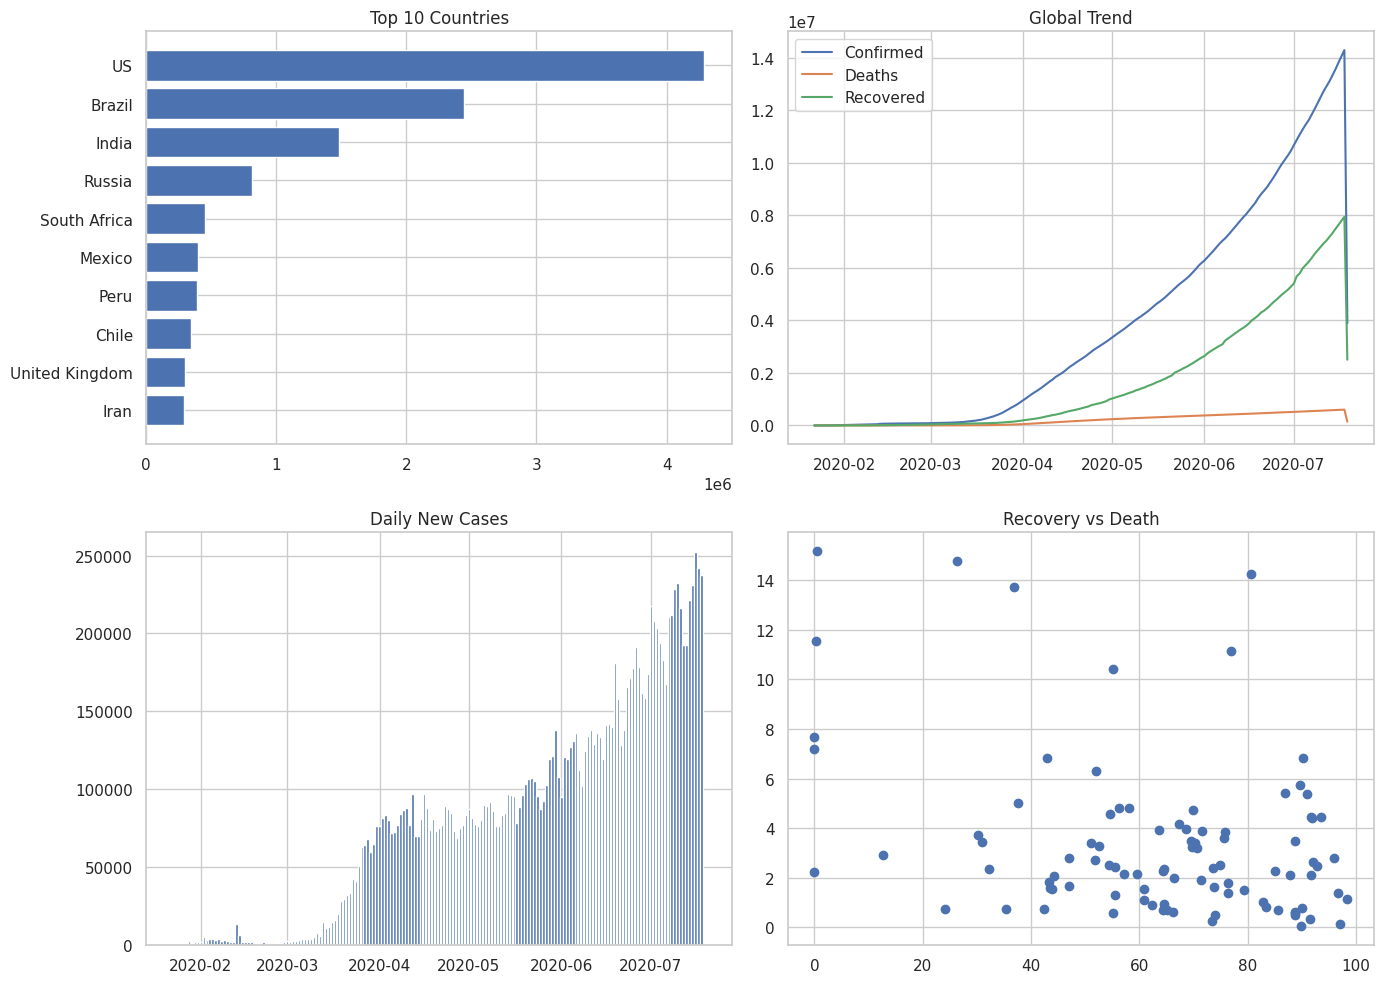

In [ ]:
plt.figure(figsize=(14, 10))

# 1. Top 10 Countries
top10 = country.sort_values('Confirmed', ascending=False).head(10)

plt.subplot(2, 2, 1)
plt.barh(top10['Country/Region'], top10['Confirmed'])
plt.gca().invert_yaxis()
plt.title('Top 10 Countries')


# 2. Global Trend
global_daily = daily.groupby('Date')[['Confirmed','Deaths','Recovered']].sum()

plt.subplot(2, 2, 2)
plt.plot(global_daily.index, global_daily['Confirmed'], label='Confirmed')
plt.plot(global_daily.index, global_daily['Deaths'], label='Deaths')
plt.plot(global_daily.index, global_daily['Recovered'], label='Recovered')
plt.title('Global Trend')
plt.legend()


# 3. Daily New Cases
global_daily['New Cases'] = global_daily['Confirmed'].diff().clip(lower=0)

plt.subplot(2, 2, 3)
plt.bar(global_daily.index, global_daily['New Cases'])
plt.title('Daily New Cases')


# 4. Recovery vs Death
country['Recovery %'] = (country['Recovered'] / country['Confirmed']) * 100
country['Death %'] = (country['Deaths'] / country['Confirmed']) * 100

data = country[country['Confirmed'] > 5000]

plt.subplot(2, 2, 4)
plt.scatter(data['Recovery %'], data['Death %'])
plt.title('Recovery vs Death')


plt.tight_layout()
plt.show()

#Key Findings
<ul><li>Global COVID-19 cases increased rapidly, showing a clear fast growth over time
<li>Death cases also increased, but slower compared to total cases
<li>Recovery numbers improved steadily, showing better treatment and response
<li>Daily new cases show multiple spikes, indicating different waves of infection
<li>A few countries contributed to a large portion of total cases
<li>There is a clear gap between the most affected countries and others
<li>Most countries have high recovery rates and low death rates
<li>Some countries show higher death rates, indicating challenges in handling the pandemic
<li>The impact of COVID-19 varies across regions, showing uneven global spread

#Reccommendations
<ul><li>Strengthen healthcare infrastructure, particularly in regions exhibiting higher mortality rates, to improve patient outcomes.
<li>Implement robust early detection and real-time monitoring systems to identify and control outbreaks promptly.
<li>Enforce timely public health interventions (e.g., mobility restrictions, social distancing) during periods of rapid case.
<li>Analyze and adopt best practices from countries demonstrating high recovery rates and effective containment strategies.
<li>Invest in healthcare capacity expansion, including hospital resources, medical staff, and emergency preparedness systems.
<li>Promote preventive measures and public awareness campaigns to reduce transmission rates at the community level.
<li>Leverage data analytics to forecast trends and prepare for future waves, enabling proactive decision-making.
<li>Encourage international collaboration and data sharing to address disparities in regional impact and response effectiveness.
<li>Maintain continuous surveillance of daily case trends to ensure swift response to emerging spikes or outbreaks.

In [ ]:
# Group data by date
global_daily = daily.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum()
print(global_daily)

             Confirmed    Deaths  Recovered
Date                                       
2020-01-22       555.0      17.0       28.0
2020-01-23       654.0      18.0       30.0
2020-01-24       941.0      26.0       36.0
2020-01-25      1434.0      42.0       39.0
2020-01-26      2118.0      56.0       52.0
...                ...       ...        ...
2020-07-15  13559984.0  583961.0  7482320.0
2020-07-16  13812525.0  589760.0  7634241.0
2020-07-17  14054563.0  596503.0  7793760.0
2020-07-18  14292198.0  602130.0  7944550.0
2020-07-19   3889707.0  143815.0  2502939.0

[180 rows x 3 columns]
